In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import RepeatedStratifiedKFold

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, "..", ".."))

# build paths inside the repo
get_data_path = lambda folders, fname: os.path.normpath(
    os.path.join(BASE_DIR, *folders, fname)
)

file_path_training_data = get_data_path(['data', 'output', 'models'], 'training_data.csv')
file_path_testing_data_parrish = get_data_path(['data','output', 'models'], 'testing_data_parrish.csv')

file_path_training_data_GIMAP = get_data_path(['data', 'output', 'models_GIMAP'], 'training_data.csv')

supplementary_figure_path = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_all_features.png')
supplementary_figure_path_GIMAP_GEMINI = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_all_features_GIMAP_GEMINI.png')
supplementary_figure_GEMINI_auc_shap = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_auc_vs_shap_contextualized.png')
supplementary_figure_GEMINI_auc_full_shap = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_auc_vs_shap_full.png')

## Supp. Fig. 2 — Feature-AUC consistency across independent screens

In [3]:
# load dataframe
df = pd.read_csv(file_path_training_data)
display(df.head())

df_parrish = pd.read_csv(file_path_testing_data_parrish)
display(df_parrish.head())

,genepair,A1,A2,A1_entrez,A2_entrez,DepMap_ID,cell_line,Gemini_FDR,raw_LFC,SL,...,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,GEMINI,LFC,SL_new
0,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000022,PATU8988S_PANCREAS,0.998944,0.088856,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.118768,0.088856,False
1,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000307,PK1_PANCREAS,0.986587,0.201704,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.132501,0.201704,False
2,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000632,HS944T_SKIN,1.000000,0.069772,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.024593,0.069772,False
3,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000681,A549_LUNG,0.977988,0.379455,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,-0.241323,0.379455,False
4,A3GALT2_ABO,A3GALT2,ABO,127550.0,28.0,ACH-000756,GI1_CENTRAL_NERVOUS_SYSTEM,0.999586,-0.077118,False,...,0.0,False,3.0,0.0,0.114847,0.258739,11.702,0.299715,-0.077118,False


,genepair,A1,A2,A1_entrez,A2_entrez,PC9_GI_score,PC9_GI_fdr,HeLa_GI_score,HeLa_GI_fdr,DepMap_ID,...,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,GEMINI,LFC,SL_new
0,A2M_PZP,A2M,PZP,2.0,5858.0,0.264313,0.138809,-0.154320,0.424612,ACH-000779,...,0.0,True,122.0,2.97235,0.601651,0.804023,473.357464,-0.249934,0.333503,False
1,A2M_PZP,A2M,PZP,2.0,5858.0,0.264313,0.138809,-0.154320,0.424612,ACH-001086,...,0.0,True,122.0,2.97235,0.601651,0.804023,473.357464,-0.038689,-0.115678,False
2,AADACL3_AADACL4,AADACL3,AADACL4,126767.0,343066.0,-0.000281,0.992873,0.120862,0.433194,ACH-000779,...,0.0,False,0.0,0.00000,0.141775,0.213038,0.350221,0.022368,-0.106713,False
3,AADACL3_AADACL4,AADACL3,AADACL4,126767.0,343066.0,-0.000281,0.992873,0.120862,0.433194,ACH-001086,...,0.0,False,0.0,0.00000,0.141775,0.213038,0.350221,-0.252247,0.257577,False
4,AADAC_AADACL2,AADAC,AADACL2,13.0,344752.0,-0.299150,0.066517,0.016004,0.951159,ACH-000779,...,0.0,False,1.0,0.00000,0.417877,2.854048,9.815447,-0.007339,-0.023724,False


In [4]:
df_GIMAP = pd.read_csv(file_path_training_data_GIMAP)
display(df_GIMAP.head())

,genepair,A1,A2,DepMap_ID,cell_line,Gemini_FDR,raw_LFC,SL,org_A1,org_A2,...,either_in_complex,mean_complex_essentiality,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,SL_new
0,A3GALT2_ABO,A3GALT2,ABO,ACH-000022,PATU8988S_PANCREAS,0.998944,0.088856,False,A3GALT2,ABO,...,0.0,0.0,0.0,0.0,3.0,0.0,0.114847,0.258739,11.702,False
1,A3GALT2_ABO,A3GALT2,ABO,ACH-000307,PK1_PANCREAS,0.986587,0.201704,False,A3GALT2,ABO,...,0.0,0.0,0.0,0.0,3.0,0.0,0.114847,0.258739,11.702,False
2,A3GALT2_ABO,A3GALT2,ABO,ACH-000632,HS944T_SKIN,1.000000,0.069772,False,A3GALT2,ABO,...,0.0,0.0,0.0,0.0,3.0,0.0,0.114847,0.258739,11.702,False
3,A3GALT2_ABO,A3GALT2,ABO,ACH-000681,A549_LUNG,0.977988,0.379455,False,A3GALT2,ABO,...,0.0,0.0,0.0,0.0,3.0,0.0,0.114847,0.258739,11.702,False
4,A3GALT2_ABO,A3GALT2,ABO,ACH-000756,GI1_CENTRAL_NERVOUS_SYSTEM,0.999586,-0.077118,False,A3GALT2,ABO,...,0.0,0.0,0.0,0.0,3.0,0.0,0.114847,0.258739,11.702,False


In [5]:
feature_columns = ['rMaxExp_A1A2', 'rMinExp_A1A2',
                     'max_ranked_A1A2', 'min_ranked_A1A2',
                     'max_cn', 'min_cn', 'Protein_Altering', 'Damaging', 
                     'min_sequence_identity',
                     'weighted_PPI_essentiality', 'weighted_PPI_expression',
                     'smallest_BP_GO_essentiality', 'smallest_CC_GO_essentiality',
                     'smallest_BP_GO_expression', 'go_CC_expression']


label = ['Gene Expression (max)', 'Gene Expression (min)',
        'Gene Essentiality (max)', 'Gene Essentiality (min)', 
        'Copy Number (max)', 'Copy Number (min)', 
        'Protein Altering Mutation', 'Damaging Mutation', 'Sequence Identity',
        'Essentiality of Shared wPPIs', 'Expression of Shared wPPIs', 
         'GO BP Essentiality (smallest)', 'GO CC Essentiality (smallest)',
         'GO BP Expression (smallest)', 'GO CC Expression (smallest)']

category = ['expression', 'expression', 
            'essentiality', 'essentiality',
            'genomic', 'genomic', 'genomic', 'genomic', 
            'sequence', 'essentiality', 'expression', 'essentiality', 'essentiality', 
             'expression', 'expression']


target_column = 'SL_new'

In [6]:
def calculate_predictive_power(df, feature_columns, target_column, labels, categories):
    data, target = df[feature_columns], df[target_column]
    
    # Define the number of folds for the cross-validation
    n_folds = 5

    # Define the number of repetitions
    n_repeats = 10
    
    # Create a RepeatedStratifiedKFold object
    rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=42)

    # Initialize lists to store the average ROC-AUC and average precision values for each feature
    mean_aucs = []
    mean_prs = []

    # Calculate baseline PR AUC
    baseline_pr_auc = np.sum(target) / len(target)
    print(f'Baseline PR AUC: {baseline_pr_auc:.4f}')

    # Iterate over each feature
    for feature_name in feature_columns:
        # Get the feature data
        feature = data[feature_name].values
        aucs = []
        aps = []

        # Calculate the ROC AUC for both positive and negative directions
        pos_direction = roc_auc_score(target, feature)
        neg_direction = roc_auc_score(target, -feature)

        # If the ROC AUC is higher for the negative direction, then flip the feature
        if neg_direction > pos_direction:
            feature = -feature

        # Perform cross-validation
        for train_index, test_index in rskf.split(feature, target):
            train_target, test_target = target[train_index], target[test_index]
            train_feature, test_feature = feature[train_index], feature[test_index]
            
            # Calculate the ROC AUC for the feature
            auc = roc_auc_score(test_target, test_feature)
            aucs.append(auc)
            
            # Calculate the average precision for the feature
            avg_precision = average_precision_score(test_target, test_feature)
            aps.append(avg_precision)

        mean_auc = np.mean(aucs)
        mean_pr = np.mean(aps)

        mean_aucs.append(mean_auc)
        mean_prs.append(mean_pr)

        print(f'Mean ROC AUC for feature {feature_name} over {n_folds * n_repeats} iterations: {mean_auc}')
        print(f'Average precision for feature {feature_name} over {n_folds * n_repeats} iterations: {mean_pr}')

    # Create a pandas DataFrame from the list of mean ROC AUC values
    pred_df = pd.DataFrame({
        'feature': feature_columns,
        'mean_roc_auc': mean_aucs,
        'avg_precision': mean_prs,
        'label': labels,
        'category': categories
    })

    # Sort the DataFrame by 'mean_roc_auc' in descending order
    pred_df = pred_df.sort_values(by='mean_roc_auc', ascending=False).reset_index(drop=True)

    # Identify the feature with the maximum ROC AUC and average precision
    max_roc_auc_feature = pred_df.loc[pred_df['mean_roc_auc'].idxmax()]
    max_pr_feature = pred_df.loc[pred_df['avg_precision'].idxmax()]

    print(f'Feature with the maximum ROC AUC value: {max_roc_auc_feature["feature"]}')
    print(f'Maximum ROC AUC value: {max_roc_auc_feature["mean_roc_auc"]}')

    print(f'Feature with the maximum average precision: {max_pr_feature["feature"]}')
    print(f'Maximum precision value: {max_pr_feature["avg_precision"]}')

    return pred_df

In [7]:
pred_df = calculate_predictive_power(df, feature_columns, target_column, label, category)
pred_df

Baseline PR AUC: 0.0232
Mean ROC AUC for feature rMaxExp_A1A2 over 50 iterations: 0.6975958233510194
Average precision for feature rMaxExp_A1A2 over 50 iterations: 0.05552380810001761
Mean ROC AUC for feature rMinExp_A1A2 over 50 iterations: 0.7096655617547215
Average precision for feature rMinExp_A1A2 over 50 iterations: 0.07112569717440005
Mean ROC AUC for feature max_ranked_A1A2 over 50 iterations: 0.7232304817347626
Average precision for feature max_ranked_A1A2 over 50 iterations: 0.09397640984520068
Mean ROC AUC for feature min_ranked_A1A2 over 50 iterations: 0.792498810656365
Average precision for feature min_ranked_A1A2 over 50 iterations: 0.11284611830277474
Mean ROC AUC for feature max_cn over 50 iterations: 0.641530593440297
Average precision for feature max_cn over 50 iterations: 0.055748528587802576
Mean ROC AUC for feature min_cn over 50 iterations: 0.5778135715311222
Average precision for feature min_cn over 50 iterations: 0.04810838516905143
Mean ROC AUC for feature Prot

,feature,mean_roc_auc,avg_precision,label,category
0,min_ranked_A1A2,0.792499,0.112846,Gene Essentiality (min),essentiality
1,max_ranked_A1A2,0.723230,0.093976,Gene Essentiality (max),essentiality
2,rMinExp_A1A2,0.709666,0.071126,Gene Expression (min),expression
3,rMaxExp_A1A2,0.697596,0.055524,Gene Expression (max),expression
4,weighted_PPI_essentiality,0.666001,0.041801,Essentiality of Shared wPPIs,essentiality
5,weighted_PPI_expression,0.657419,0.043151,Expression of Shared wPPIs,expression
6,max_cn,0.641531,0.055749,Copy Number (max),genomic
7,smallest_BP_GO_essentiality,0.606904,0.057082,GO BP Essentiality (smallest),essentiality
8,smallest_BP_GO_expression,0.601744,0.069968,GO BP Expression (smallest),expression
9,min_cn,0.577814,0.048108,Copy Number (min),genomic


In [8]:
pred_parrish_df = calculate_predictive_power(df_parrish, feature_columns, target_column, label, category)
pred_parrish_df

Baseline PR AUC: 0.0782
Mean ROC AUC for feature rMaxExp_A1A2 over 50 iterations: 0.6920000546828768
Average precision for feature rMaxExp_A1A2 over 50 iterations: 0.1513894332122074
Mean ROC AUC for feature rMinExp_A1A2 over 50 iterations: 0.7663967619746761
Average precision for feature rMinExp_A1A2 over 50 iterations: 0.22752690197941677
Mean ROC AUC for feature max_ranked_A1A2 over 50 iterations: 0.6222543672641832
Average precision for feature max_ranked_A1A2 over 50 iterations: 0.14681319727481712
Mean ROC AUC for feature min_ranked_A1A2 over 50 iterations: 0.6357750850830606
Average precision for feature min_ranked_A1A2 over 50 iterations: 0.19224001158092577
Mean ROC AUC for feature max_cn over 50 iterations: 0.5791436184583424
Average precision for feature max_cn over 50 iterations: 0.09820247168894129
Mean ROC AUC for feature min_cn over 50 iterations: 0.571128783418354
Average precision for feature min_cn over 50 iterations: 0.10470890121262683
Mean ROC AUC for feature Prote

,feature,mean_roc_auc,avg_precision,label,category
0,rMinExp_A1A2,0.766397,0.227527,Gene Expression (min),expression
1,weighted_PPI_essentiality,0.730609,0.209490,Essentiality of Shared wPPIs,essentiality
2,weighted_PPI_expression,0.711630,0.184774,Expression of Shared wPPIs,expression
3,rMaxExp_A1A2,0.692000,0.151389,Gene Expression (max),expression
4,smallest_BP_GO_expression,0.648535,0.208319,GO BP Expression (smallest),expression
5,min_ranked_A1A2,0.635775,0.192240,Gene Essentiality (min),essentiality
6,max_ranked_A1A2,0.622254,0.146813,Gene Essentiality (max),essentiality
7,smallest_BP_GO_essentiality,0.619486,0.189972,GO BP Essentiality (smallest),essentiality
8,go_CC_expression,0.606751,0.167460,GO CC Expression (smallest),expression
9,smallest_CC_GO_essentiality,0.599912,0.166408,GO CC Essentiality (smallest),essentiality


In [9]:
pred_GIMAP_df = calculate_predictive_power(df_GIMAP, feature_columns, target_column, label, category)
pred_GIMAP_df

Baseline PR AUC: 0.0059
Mean ROC AUC for feature rMaxExp_A1A2 over 50 iterations: 0.7177784882609278
Average precision for feature rMaxExp_A1A2 over 50 iterations: 0.01794810538911765
Mean ROC AUC for feature rMinExp_A1A2 over 50 iterations: 0.7556076955715324
Average precision for feature rMinExp_A1A2 over 50 iterations: 0.03884389388430778
Mean ROC AUC for feature max_ranked_A1A2 over 50 iterations: 0.6328191778866176
Average precision for feature max_ranked_A1A2 over 50 iterations: 0.0121150485443851
Mean ROC AUC for feature min_ranked_A1A2 over 50 iterations: 0.7198837351470755
Average precision for feature min_ranked_A1A2 over 50 iterations: 0.01558678832333371
Mean ROC AUC for feature max_cn over 50 iterations: 0.5871753520512337
Average precision for feature max_cn over 50 iterations: 0.010641292886989076
Mean ROC AUC for feature min_cn over 50 iterations: 0.5191305266806556
Average precision for feature min_cn over 50 iterations: 0.006952680901233335
Mean ROC AUC for feature Pr

,feature,mean_roc_auc,avg_precision,label,category
0,rMinExp_A1A2,0.755608,0.038844,Gene Expression (min),expression
1,min_ranked_A1A2,0.719884,0.015587,Gene Essentiality (min),essentiality
2,rMaxExp_A1A2,0.717778,0.017948,Gene Expression (max),expression
3,weighted_PPI_expression,0.673124,0.012517,Expression of Shared wPPIs,expression
4,weighted_PPI_essentiality,0.660818,0.010710,Essentiality of Shared wPPIs,essentiality
5,max_ranked_A1A2,0.632819,0.012115,Gene Essentiality (max),essentiality
6,min_sequence_identity,0.614677,0.040019,Sequence Identity,sequence
7,smallest_BP_GO_expression,0.608153,0.062819,GO BP Expression (smallest),expression
8,max_cn,0.587175,0.010641,Copy Number (max),genomic
9,smallest_BP_GO_essentiality,0.567709,0.014773,GO BP Essentiality (smallest),essentiality


In [10]:
# Assuming both DataFrames have a common identifier column, e.g., 'id'
common_column = 'feature'

# Set the index of both DataFrames to the common column
pred_parrish_df.set_index(common_column, inplace=True)
pred_df.set_index(common_column, inplace=True)
pred_GIMAP_df.set_index(common_column, inplace=True)

# Reindex pred_parrish_df to match the order of pred_df
pred_parrish_df = pred_parrish_df.reindex(pred_df.index)
pred_GIMAP_df = pred_GIMAP_df.reindex(pred_df.index)

# Reset the index if needed
pred_parrish_df.reset_index(inplace=True)
pred_df.reset_index(inplace=True)
pred_GIMAP_df.reset_index(inplace=True)

In [11]:
pred_df

,feature,mean_roc_auc,avg_precision,label,category
0,min_ranked_A1A2,0.792499,0.112846,Gene Essentiality (min),essentiality
1,max_ranked_A1A2,0.723230,0.093976,Gene Essentiality (max),essentiality
2,rMinExp_A1A2,0.709666,0.071126,Gene Expression (min),expression
3,rMaxExp_A1A2,0.697596,0.055524,Gene Expression (max),expression
4,weighted_PPI_essentiality,0.666001,0.041801,Essentiality of Shared wPPIs,essentiality
5,weighted_PPI_expression,0.657419,0.043151,Expression of Shared wPPIs,expression
6,max_cn,0.641531,0.055749,Copy Number (max),genomic
7,smallest_BP_GO_essentiality,0.606904,0.057082,GO BP Essentiality (smallest),essentiality
8,smallest_BP_GO_expression,0.601744,0.069968,GO BP Expression (smallest),expression
9,min_cn,0.577814,0.048108,Copy Number (min),genomic


In [12]:
pred_parrish_df

,feature,mean_roc_auc,avg_precision,label,category
0,min_ranked_A1A2,0.635775,0.192240,Gene Essentiality (min),essentiality
1,max_ranked_A1A2,0.622254,0.146813,Gene Essentiality (max),essentiality
2,rMinExp_A1A2,0.766397,0.227527,Gene Expression (min),expression
3,rMaxExp_A1A2,0.692000,0.151389,Gene Expression (max),expression
4,weighted_PPI_essentiality,0.730609,0.209490,Essentiality of Shared wPPIs,essentiality
5,weighted_PPI_expression,0.711630,0.184774,Expression of Shared wPPIs,expression
6,max_cn,0.579144,0.098202,Copy Number (max),genomic
7,smallest_BP_GO_essentiality,0.619486,0.189972,GO BP Essentiality (smallest),essentiality
8,smallest_BP_GO_expression,0.648535,0.208319,GO BP Expression (smallest),expression
9,min_cn,0.571129,0.104709,Copy Number (min),genomic


In [13]:
pred_GIMAP_df

,feature,mean_roc_auc,avg_precision,label,category
0,min_ranked_A1A2,0.719884,0.015587,Gene Essentiality (min),essentiality
1,max_ranked_A1A2,0.632819,0.012115,Gene Essentiality (max),essentiality
2,rMinExp_A1A2,0.755608,0.038844,Gene Expression (min),expression
3,rMaxExp_A1A2,0.717778,0.017948,Gene Expression (max),expression
4,weighted_PPI_essentiality,0.660818,0.010710,Essentiality of Shared wPPIs,essentiality
5,weighted_PPI_expression,0.673124,0.012517,Expression of Shared wPPIs,expression
6,max_cn,0.587175,0.010641,Copy Number (max),genomic
7,smallest_BP_GO_essentiality,0.567709,0.014773,GO BP Essentiality (smallest),essentiality
8,smallest_BP_GO_expression,0.608153,0.062819,GO BP Expression (smallest),expression
9,min_cn,0.519131,0.006953,Copy Number (min),genomic


In [14]:
# spearman correlation
x = pred_df['mean_roc_auc']
y = pred_parrish_df['mean_roc_auc']
correlation, p_value = spearmanr(x, y)

print(f'Spearman ρ = {correlation:.3f}  (p = {p_value:.2e})')

Spearman ρ = 0.789  (p = 4.67e-04)


In [15]:
category_color = {
    'essentiality': "#009E73",
    'expression':   "#56B4E9",
    'genomic':      '#0072B2',
    'sequence':     "#E69F00",
    'neighborhood': "#D55E00",
}

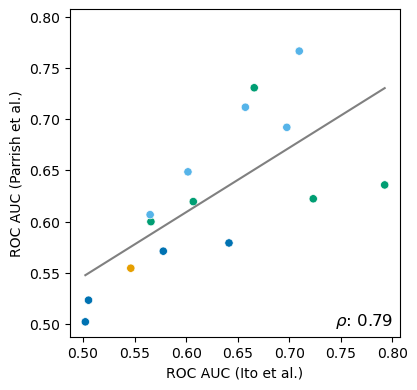

In [16]:
# Create a scatterplot with a regression line
fig, ax = plt.subplots(figsize=(4.25, 4.25))
sns.scatterplot(x=x, y=y, ax=ax, hue=pred_df['category'], palette=category_color, legend=False)

# Calculate and plot regression line for the full dataset
slope, intercept = np.polyfit(x, y, 1)

order = np.argsort(x)
ax.plot(x.iloc[order], slope * x.iloc[order] + intercept, color='grey')
ax.text(0.98, 0.02, f'$\\rho$: {correlation:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right')

# Equalize axes
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
pad = (hi - lo) * 0.05
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)

plt.xlabel('ROC AUC (Ito et al.)')
plt.ylabel('ROC AUC (Parrish et al.)')
plt.show()

#fig.savefig(supplementary_figure_path, bbox_inches='tight', dpi=500)

In [17]:
# correlation with GIMAP
x_g = pred_GIMAP_df['mean_roc_auc']
y_g = pred_df['mean_roc_auc']

spearman_correlation, spearman_p_value = spearmanr(x_g, y_g)
print(f'Spearman ρ = {spearman_correlation:.3f}  (p = {spearman_p_value:.2e})')

Spearman ρ = 0.854  (p = 5.17e-05)


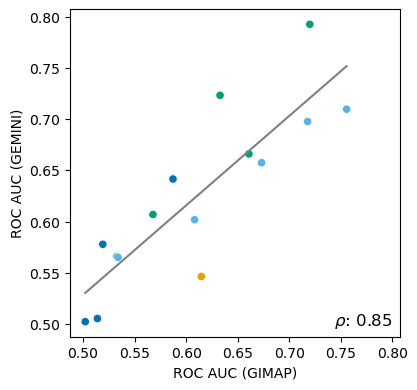

In [18]:
# Scatterplot for GIMAP
fig, ax = plt.subplots(figsize=(4.25, 4.25))
sns.scatterplot(x=x_g, y=y_g, ax=ax, 
                hue=pred_GIMAP_df['category'], palette=category_color, legend=False)

slope, intercept = np.polyfit(x_g, y_g, 1)

order = np.argsort(x_g)
ax.plot(x_g.iloc[order], slope * x_g.iloc[order] + intercept, color='grey')

ax.text(0.98, 0.02, f'$\\rho$: {spearman_correlation:.2f}',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='right')

# Equalize axes
lo = min(x_g.min(), y_g.min())
hi = max(x_g.max(), y_g.max())
pad = (hi - lo) * 0.05
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)

plt.xlabel('ROC AUC (GIMAP)')
plt.ylabel('ROC AUC (GEMINI)')
plt.show()

#fig.savefig(supplementary_figure_path_GIMAP_GEMINI, bbox_inches='tight', dpi=500)


## Supp. Fig. 6 — ROC AUC vs. mean |SHAP| (contextualised & full models)

In [21]:
shap_contextualised_df = pd.read_csv(
    get_data_path(['data', 'output', 'models'], 'shap_importance_contextualised_complete_dataset.csv')
).rename(columns={'feature_label': 'label'})

merge_pred_shap = pd.merge(pred_df, shap_contextualised_df, on=['feature', 'label'], how='left')

merge_pred_shap[:3]

,feature,mean_roc_auc,avg_precision,label,category,mean_abs_shap
0,min_ranked_A1A2,0.792499,0.112846,Gene Essentiality (min),essentiality,0.011134
1,max_ranked_A1A2,0.723230,0.093976,Gene Essentiality (max),essentiality,0.007823
2,rMinExp_A1A2,0.709666,0.071126,Gene Expression (min),expression,0.008021


In [22]:
x_auc = merge_pred_shap['mean_roc_auc']
y_shap = merge_pred_shap['mean_abs_shap']
correlation, p_value = pearsonr(x_auc, y_shap)
print(f'Pearson ρ = {correlation:.3f}  (p = {p_value:.2e})')

spearman_correlation, spearman_p_value = spearmanr(x_auc, y_shap)
print(f'Spearman ρ = {spearman_correlation:.3f}  (p = {spearman_p_value:.2e})')

Pearson ρ = 0.846  (p = 6.96e-05)
Spearman ρ = 0.836  (p = 1.04e-04)


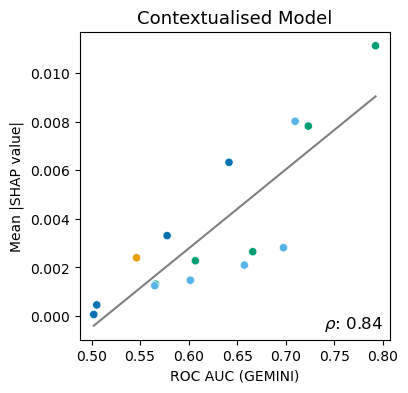

In [23]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(
    x=x_auc, y=y_shap, ax=ax,
    hue=merge_pred_shap['category'],
    palette={'essentiality': "#009E73",
             'expression':   "#56B4E9",
             'genomic':      '#0072B2',
             'sequence':     "#E69F00"},
    legend=False,
)

slope, intercept = np.polyfit(x_auc, y_shap, 1)
order = np.argsort(x)
ax.plot(x.iloc[order], slope * x.iloc[order] + intercept, color='grey')

ax.text(0.98, 0.02, f'$\\rho$: {spearman_correlation:.2f}',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='right')

# Equalize axes
#lo = min(x_auc.min(), y_shap.min())
#hi = max(x_auc.max(), y_shap.max())
#pad = (hi - lo) * 0.05
#ax.set_xlim(0.50, 0.82)
#ax.set_ylim(0.000060, 0.012)

from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # optional, for x-axis too

ax.set_title('Contextualised Model', fontsize=13)

plt.xlabel('ROC AUC (GEMINI)')
plt.ylabel('Mean |SHAP value|')
plt.show()

#supplementary_figure_GEMINI_auc_shap = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_auc_vs_shap_contextualized.png')
#fig.savefig(supplementary_figure_GEMINI_auc_shap, bbox_inches='tight', dpi=500)


In [24]:
# Full feature set — build feature_columns, labels, categories
feature_labels_full = {
    'rMaxExp_A1A2':                 'Gene Expression (max)',
    'rMinExp_A1A2':                 'Gene Expression (min)',
    'max_ranked_A1A2':              'Gene Essentiality (max)',
    'min_ranked_A1A2':              'Gene Essentiality (min)',
    'max_cn':                       'Copy Number (max)',
    'min_cn':                       'Copy Number (min)',
    'Protein_Altering':             'Protein Altering Mutation',
    'Damaging':                     'Damaging Mutation',
    'min_sequence_identity':        'Sequence Identity',
    'weighted_PPI_essentiality':    'Essentiality of Shared wPPIs',
    'weighted_PPI_expression':      'Expression of Shared wPPIs',
    'smallest_BP_GO_essentiality':  'GO BP Essentiality (smallest)',
    'smallest_CC_GO_essentiality':  'GO CC Essentiality (smallest)',
    'smallest_BP_GO_expression':    'GO BP Expression (smallest)',
    'go_CC_expression':             'GO CC Expression (smallest)',
    'closest':                             'Closest Paralog',
    'WGD':                                 'Whole Genome Duplicates',
    'family_size':                         'Family Size',
    'cds_length_ratio':                    'Gene Length Ratio',
    'shared_domains':                      'Shared Domains',
    'has_pombe_ortholog':                  r'$\it{S.\ pombe}$ ortholog',
    'has_essential_pombe_ortholog':        r'Essential $\it{S.\ pombe}$ ortholog',
    'has_cerevisiae_ortholog':             r'$\it{S.\ cerevisiae}$ ortholog',
    'has_essential_cerevisiae_ortholog':   r'Essential $\it{S.\ cerevisiae}$ ortholog',
    'conservation_score':                  'Conservation Score',
    'mean_age':                            'Gene Age',
    'either_in_complex':                   'Protein Complex Membership',
    'mean_complex_essentiality':           'Essentiality of Protein Complex(es)',
    'colocalisation':                      'Colocalisation',
    'interact':                            'Protein-Protein Interaction',
    'n_total_ppi':                         'Total Protein-Protein Interactors',
    'fet_ppi_overlap':                     'Protein-Protein Interactors',
    'gtex_spearman_corr':                  'Expression Correlation',
    'gtex_min_mean_expr':                  'Mean expression (Lower)',
    'gtex_max_mean_expr':                  'Mean Expression (Higher)',
}

feature_category_full = {
    'rMaxExp_A1A2':                 'expression',
    'rMinExp_A1A2':                 'expression',
    'max_ranked_A1A2':              'essentiality',
    'min_ranked_A1A2':              'essentiality',
    'max_cn':                       'genomic',
    'min_cn':                       'genomic',
    'Protein_Altering':             'genomic',
    'Damaging':                     'genomic',
    'min_sequence_identity':        'sequence',
    'weighted_PPI_essentiality':    'essentiality',
    'weighted_PPI_expression':      'expression',
    'smallest_BP_GO_essentiality':  'essentiality',
    'smallest_CC_GO_essentiality':  'essentiality',
    'smallest_BP_GO_expression':    'expression',
    'go_CC_expression':             'expression',
    'closest':                             'sequence',
    'WGD':                                 'sequence',
    'family_size':                         'sequence',
    'cds_length_ratio':                    'sequence',
    'shared_domains':                      'sequence',
    'has_pombe_ortholog':                  'sequence',
    'has_essential_pombe_ortholog':        'sequence',
    'has_cerevisiae_ortholog':             'sequence',
    'has_essential_cerevisiae_ortholog':   'sequence',
    'conservation_score':                  'sequence',
    'mean_age':                            'sequence',
    'either_in_complex':                   'neighborhood',
    'mean_complex_essentiality':           'neighborhood',
    'colocalisation':                      'neighborhood',
    'interact':                            'neighborhood',
    'n_total_ppi':                         'neighborhood',
    'fet_ppi_overlap':                     'neighborhood',
    'gtex_spearman_corr':                  'expression',
    'gtex_min_mean_expr':                  'expression',
    'gtex_max_mean_expr':                  'expression',
}

feature_columns_full = list(feature_labels_full.keys())
labels_full          = [feature_labels_full[f]   for f in feature_columns_full]
categories_full      = [feature_category_full[f] for f in feature_columns_full]

In [28]:
df_full = df.copy()
df_full[feature_columns_full] = df_full[feature_columns_full].astype(float)

pred_full_df = calculate_predictive_power(df_full, feature_columns_full, target_column, labels_full, categories_full)
pred_full_df

Baseline PR AUC: 0.0232
Mean ROC AUC for feature rMaxExp_A1A2 over 50 iterations: 0.6975958233510194
Average precision for feature rMaxExp_A1A2 over 50 iterations: 0.05552380810001761
Mean ROC AUC for feature rMinExp_A1A2 over 50 iterations: 0.7096655617547215
Average precision for feature rMinExp_A1A2 over 50 iterations: 0.07112569717440005
Mean ROC AUC for feature max_ranked_A1A2 over 50 iterations: 0.7232304817347626
Average precision for feature max_ranked_A1A2 over 50 iterations: 0.09397640984520068
Mean ROC AUC for feature min_ranked_A1A2 over 50 iterations: 0.792498810656365
Average precision for feature min_ranked_A1A2 over 50 iterations: 0.11284611830277474
Mean ROC AUC for feature max_cn over 50 iterations: 0.641530593440297
Average precision for feature max_cn over 50 iterations: 0.055748528587802576
Mean ROC AUC for feature min_cn over 50 iterations: 0.5778135715311222
Average precision for feature min_cn over 50 iterations: 0.04810838516905143
Mean ROC AUC for feature Prot

,feature,mean_roc_auc,avg_precision,label,category
0,min_ranked_A1A2,0.792499,0.112846,Gene Essentiality (min),essentiality
1,max_ranked_A1A2,0.723230,0.093976,Gene Essentiality (max),essentiality
2,n_total_ppi,0.711057,0.053343,Total Protein-Protein Interactors,neighborhood
3,rMinExp_A1A2,0.709666,0.071126,Gene Expression (min),expression
4,rMaxExp_A1A2,0.697596,0.055524,Gene Expression (max),expression
5,fet_ppi_overlap,0.693632,0.077164,Protein-Protein Interactors,neighborhood
6,conservation_score,0.677428,0.041691,Conservation Score,sequence
7,weighted_PPI_essentiality,0.666001,0.041801,Essentiality of Shared wPPIs,essentiality
8,weighted_PPI_expression,0.657419,0.043151,Expression of Shared wPPIs,expression
9,gtex_min_mean_expr,0.650194,0.041005,Mean expression (Lower),expression


In [29]:
shap_full_df = pd.read_csv(
    get_data_path(['data', 'output', 'models'], 'shap_importance_full_full.csv')
).rename(columns={'feature_label': 'label'})

merge_pred_shap_full = pd.merge(pred_full_df, shap_full_df, on=['feature', 'label'], how='left')

merge_pred_shap_full[:3]

,feature,mean_roc_auc,avg_precision,label,category,mean_abs_shap
0,min_ranked_A1A2,0.792499,0.112846,Gene Essentiality (min),essentiality,0.010985
1,max_ranked_A1A2,0.723230,0.093976,Gene Essentiality (max),essentiality,0.007029
2,n_total_ppi,0.711057,0.053343,Total Protein-Protein Interactors,neighborhood,0.003019


In [30]:
x_auc  = merge_pred_shap_full['mean_roc_auc']
y_shap = merge_pred_shap_full['mean_abs_shap']

correlation, p_value = pearsonr(x_auc, y_shap)
print(f'Pearson ρ = {correlation:.3f}  (p = {p_value:.2e})')

spearman_correlation, spearman_p_value = spearmanr(x_auc, y_shap)
print(f'Spearman ρ = {spearman_correlation:.3f}  (p = {spearman_p_value:.2e})')

Pearson ρ = 0.735  (p = 4.97e-07)
Spearman ρ = 0.674  (p = 9.08e-06)


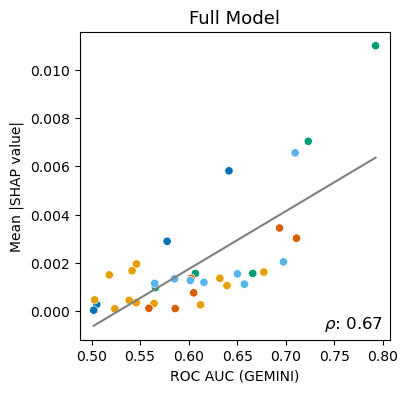

In [31]:
category_color = {
    'essentiality': "#009E73",
    'expression':   "#56B4E9",
    'genomic':      '#0072B2',
    'sequence':     "#E69F00",
    'neighborhood': "#D55E00",
}

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(
    x=x_auc, y=y_shap, ax=ax,
    hue=merge_pred_shap_full['category'],
    palette=category_color,
    legend=False,
)

slope, intercept = np.polyfit(x_auc, y_shap, 1)
order = np.argsort(x)
ax.plot(x.iloc[order], slope * x.iloc[order] + intercept, color='grey')

ax.text(0.98, 0.02, f'$\\rho$: {spearman_correlation:.2f}',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', horizontalalignment='right')

from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

ax.set_title('Full Model', fontsize=13)

plt.xlabel('ROC AUC (GEMINI)')
plt.ylabel('Mean |SHAP value|')
plt.show()

#supplementary_figure_GEMINI_auc_full_shap = get_data_path(['figures', 'supp_figures'], 'scatter_plot_of_auc_vs_shap_full.png')
#fig.savefig(supplementary_figure_GEMINI_auc_full_shap, bbox_inches='tight', dpi=500)

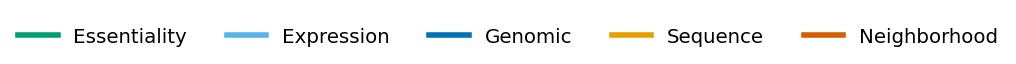

In [32]:
category_display = {
    'essentiality': 'Essentiality',
    'expression':   'Expression',
    'genomic':      'Genomic',
    'sequence':     'Sequence',
    'neighborhood': 'Neighborhood',
}

legend_labels = list(category_display.values())
legend_styles = [{"color": category_color[c], "linestyle": "-"} for c in category_display.keys()]

plt.figure(figsize=(9, 0.10))
for style in legend_styles:
    plt.plot([], [], color=style["color"], linestyle=style["linestyle"], linewidth=4)

plt.legend(
    legend_labels,
    fontsize=14.25,
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
)
plt.gca().set_axis_off()

#plt.savefig(
#    get_data_path(['figures', 'supp_figures'],
#                  'scatter_plot_of_auc_vs_shap_full_legend.png'),
#    bbox_inches='tight', dpi=600,
#)
plt.show()
